# Streaming Platform Database Project

                                                Name: Arman Ali Zaib        Student ID: 24168194

## Project Overview

This notebook presents the design and generation of a relational database for a fictional streaming platform. The aim of the project is to simulate how a real-world streaming service might store and manage information related to users, movies, watch activity, subscription payments, ratings, and user engagement.

The dataset is generated using synthetic data in order to maintain ethical standards and avoid the use of real personal information. Randomised values are used to produce realistic variations in user behaviour, content metadata, and engagement patterns.

The final database contains multiple relational tables with foreign key relationships and includes more than 1000 records in several interaction tables in order to reflect the high volume of activity typically observed in streaming platforms.

In [1]:
import sqlite3
import random
import pandas as pd
from faker import Faker
from datetime import datetime, timedelta

print("Importing libraries")

Importing libraries


In [2]:
conn = sqlite3.connect("streaming_platform.db")
cursor = conn.cursor()

# Enable foreign key support
cursor.execute("PRAGMA foreign_keys = ON;")

print("Database created successfully")

Database created successfully


## Database Purpose and Design Rationale

The purpose of this database is to model the core components of a streaming platform. The database structure captures key entities and interactions typically present in real streaming services.

The system stores information about:

- Users who subscribe to the platform
- Movies available for streaming
- Watch history recording viewing behaviour
- User ratings for movies
- Subscription payments
- Engagement metrics based on viewing activity

Each table represents a separate real-world entity. Interaction tables such as Watch_History, Ratings, and Engagement contain significantly more records than the content tables because user actions occur far more frequently than content creation. This scaling mirrors how real streaming platforms generate large volumes of behavioural data.

## Table Structure and Justification

### Users Table
Stores user profile information such as name, email, subscription type, and account details. Each user is uniquely identified by `User_ID`.

### Movies Table
Contains metadata about available content, including title, genre, release year, and duration. This supports content categorisation and recommendation analysis.

### Watch_History Table
Records when users watch movies. This table captures behavioural interaction data and is one of the largest tables in the database.

### Ratings Table
Stores user feedback on movies through rating values, enabling analysis of content popularity and user preferences.

### Payments Table
Tracks subscription payments made by users. This table represents financial transactions related to the service.

### Engagement Table
Measures user interaction intensity through metrics such as minutes watched, allowing behavioural analysis of platform usage.

## Primary Keys, Foreign Keys and Relationships

Each table includes a primary key to uniquely identify records and ensure entity integrity.

Foreign keys are used to establish relationships between tables:

- `User_ID` connects the Users table with Watch_History, Ratings, Payments, and Engagement.
- `Movie_ID` connects the Movies table with Watch_History, Ratings, and Engagement.

These relationships allow the database to model many-to-many interactions between users and movies through join tables such as Ratings and Watch_History.

Composite keys are also used in interaction tables. For example, the Ratings table uses the combination of `User_ID` and `Movie_ID` to prevent a user from rating the same movie multiple times.

In [3]:
cursor.execute("""
CREATE TABLE Movies (
    Movie_ID INTEGER PRIMARY KEY AUTOINCREMENT,
    
    Title TEXT NOT NULL UNIQUE,
    
    Genre TEXT,  
    Age_Rating TEXT CHECK (Age_Rating IN ('G','PG','12','15','18')),
    
    Release_Year INTEGER,
    Duration_Minutes INTEGER CHECK (Duration_Minutes > 0),
    
    Budget REAL CHECK (Budget >= 0),
    IMDb_Rating REAL CHECK (IMDb_Rating BETWEEN 1 AND 10),
    
    Language TEXT
);
""")

conn.commit()

print("Movies table recreated")

Movies table recreated


In [4]:
cursor.execute("""
CREATE TABLE Users (
    User_ID INTEGER PRIMARY KEY AUTOINCREMENT,
    Full_Name TEXT,
    Email TEXT UNIQUE,
    Country TEXT,
    Subscription_Type TEXT,
    Date_Joined TEXT,
    Age INTEGER
)
""")

conn.commit()

print("Users table recreated")

Users table recreated


In [5]:
cursor.execute("""
CREATE TABLE Ratings (
    Rating_ID INTEGER PRIMARY KEY AUTOINCREMENT,
    User_ID INTEGER,
    Movie_ID INTEGER,
    Rating INTEGER,
    FOREIGN KEY(User_ID) REFERENCES Users(User_ID),
    FOREIGN KEY(Movie_ID) REFERENCES Movies(Movie_ID)
)
""")

conn.commit()

print("Ratings table recreated")

Ratings table recreated


In [6]:
cursor.execute("""
CREATE TABLE Watch_History (
    Watch_ID INTEGER PRIMARY KEY AUTOINCREMENT,
    User_ID INTEGER,
    Movie_ID INTEGER,
    Watch_Date TEXT,
    FOREIGN KEY(User_ID) REFERENCES Users(User_ID),
    FOREIGN KEY(Movie_ID) REFERENCES Movies(Movie_ID)
)
""")

conn.commit()

print("Watch History table recreated")

Watch History table recreated


In [7]:
cursor.execute("""
CREATE TABLE Payments (
    Payment_ID INTEGER PRIMARY KEY AUTOINCREMENT,
    User_ID INTEGER,
    Amount REAL,
    Payment_Date TEXT,
    FOREIGN KEY(User_ID) REFERENCES Users(User_ID)
)
""")

conn.commit()

print("Payments table recreated")

Payments table recreated


In [8]:
cursor.execute("""
CREATE TABLE Engagement (
    Engagement_ID INTEGER PRIMARY KEY AUTOINCREMENT,
    User_ID INTEGER,
    Movie_ID INTEGER,
    Minutes_Watched INTEGER,
    FOREIGN KEY(User_ID) REFERENCES Users(User_ID),
    FOREIGN KEY(Movie_ID) REFERENCES Movies(Movie_ID)
)
""")

conn.commit()

print("Engagement table recreated")

Engagement table recreated


## Data Generation and Database Realism

The dataset was generated using randomized logic to simulate realistic streaming platform data. Synthetic data allows the database structure and behaviour to be tested without using real user information.

Different tables were generated with varying sizes to reflect real-world platform dynamics. Behavioural tables such as Watch_History, Ratings, and Engagement contain significantly more records than the Users or Movies tables because user interactions occur frequently on streaming services.

To increase realism, missing values were intentionally introduced into selected attributes. For example, a small proportion of demographic fields (approximately 2–5%) contain missing values, while behavioural and financial attributes contain higher levels of missing data. This reflects real-world datasets where incomplete records are common.

Random distributions were also used when generating ratings, engagement metrics, and payment records to avoid unrealistic uniform data patterns.
## Dataset Scale

The database was designed with varying table sizes to reflect realistic streaming platform data volumes.

- Users: 1100 records
- Movies: 300 records
- Watch_History: 2000 records
- Ratings: 1200 records
- Payments: 1200 records
- Engagement: 1500 records

Interaction tables are intentionally larger because user activity generates many more records than content creation.

In [9]:
import random


# Movie title components
adjectives = [
    "Dark", "Silent", "Crimson", "Lost", "Broken", "Hidden",
    "Eternal", "Fallen", "Rising", "Golden", "Shattered",
    "Midnight", "Burning", "Frozen", "Scarlet", "Forgotten"
]

nouns = [
    "Empire", "Kingdom", "Horizon", "Legacy", "Shadow",
    "Dreams", "Reckoning", "Storm", "Prophecy", "Odyssey",
    "Secrets", "Rebellion", "Destiny", "Awakening", "Frontier",
    "Chronicles", "Sanctuary", "Alliance"
]

subtitle_words = ["Rise", "Fall", "Return", "Revenge", "Origins", "Awakening"]

genres = ["Action", "Drama", "Comedy", "Thriller", "Sci-Fi", "Horror"]
age_ratings = ["G", "PG", "12", "15", "18"]
languages = ["English", "French", "Spanish", "German"]

def generate_movie_title():
    main_title = f"{random.choice(adjectives)} {random.choice(nouns)}"
    
    # 40% chance of subtitle
    if random.random() > 0.6:
        return f"{main_title}: {random.choice(subtitle_words)}"
    
    return main_title


used_titles = set()

while len(used_titles) < 300: 
    
    title = generate_movie_title()
    
    if title in used_titles:
        continue
        
    used_titles.add(title)
    
    genre = random.choice(genres) if random.random() > 0.02 else None
    age_rating = random.choice(age_ratings) if random.random() > 0.03 else None
    release_year = random.randint(1980, 2024) if random.random() > 0.02 else None
    duration = random.randint(80, 180) if random.random() > 0.05 else None
    budget = round(random.uniform(1_000_000, 200_000_000), 2) if random.random() > 0.25 else None
    imdb_rating = round(random.uniform(1, 10), 1) if random.random() > 0.10 else None
    language = random.choice(languages) if random.random() > 0.03 else None

    cursor.execute("""
    INSERT INTO Movies
    (Title, Genre, Age_Rating, Release_Year, Duration_Minutes, Budget, IMDb_Rating, Language)
    VALUES (?, ?, ?, ?, ?, ?, ?, ?)
    """, (
        title,
        genre,
        age_rating,
        release_year,
        duration,
        budget,
        imdb_rating,
        language
    ))

conn.commit()

print("Cinematic movies inserted")

Cinematic movies inserted


In [10]:
fake = Faker()

countries = ["USA", "UK", "France", "Canada"]
subscriptions = ["Basic", "Standard", "Premium"]

for i in range(1, 1100):

    full_name = fake.name()
    email_name = full_name.lower().replace(" ", "")
    email = f"{email_name}{random.randint(100,999)}@gmail.com"

    join_date = datetime.now() - timedelta(days=random.randint(0, 1000))

    age = random.randint(18, 65) if random.random() > 0.05 else None
    country = random.choice(countries) if random.random() > 0.03 else None
    subscription = random.choice(subscriptions) if random.random() > 0.02 else None
    date_joined = join_date.strftime("%Y-%m-%d") if random.random() > 0.02 else None

    cursor.execute("""
    INSERT INTO Users 
    (Full_Name, Email, Country, Subscription_Type, Date_Joined, Age)
    VALUES (?, ?, ?, ?, ?, ?)
    """, (
        full_name,
        email,
        country,
        subscription,
        date_joined,
        age
    ))

conn.commit()

print("Users inserted")

Users inserted


In [11]:
for _ in range(1200):

    rating = random.randint(1, 5) if random.random() > 0.10 else None

    cursor.execute("""
    INSERT INTO Ratings (User_ID, Movie_ID, Rating)
    VALUES (?, ?, ?)
    """, (
        random.randint(1, 30),
        random.randint(1, 50),
        rating
    ))

conn.commit()

print("Ratings inserted")

Ratings inserted


In [12]:
for _ in range(2000):

    watch_date = (
        (datetime.now() - timedelta(days=random.randint(0, 365))).strftime("%Y-%m-%d")
        if random.random() > 0.10 else None
    )

    cursor.execute("""
    INSERT INTO Watch_History (User_ID, Movie_ID, Watch_Date)
    VALUES (?, ?, ?)
    """, (
        random.randint(1, 30),
        random.randint(1, 50),
        watch_date
    ))

conn.commit()

print("Watch history inserted")

Watch history inserted


In [13]:
for _ in range(1200):

    amount = random.choice([9.99, 14.99, 19.99]) if random.random() > 0.10 else None
    payment_date = (
        (datetime.now() - timedelta(days=random.randint(0, 365))).strftime("%Y-%m-%d")
        if random.random() > 0.10 else None
    )

    cursor.execute("""
    INSERT INTO Payments (User_ID, Amount, Payment_Date)
    VALUES (?, ?, ?)
    """, (
        random.randint(1, 30),
        amount,
        payment_date
    ))

conn.commit()

print("Payments inserted")

Payments inserted


In [14]:
for _ in range(1500):

    minutes = random.randint(10, 180) if random.random() > 0.10 else None

    cursor.execute("""
    INSERT INTO Engagement (User_ID, Movie_ID, Minutes_Watched)
    VALUES (?, ?, ?)
    """, (
        random.randint(1, 30),
        random.randint(1, 50),
        minutes
    ))

conn.commit()

print("Engagement inserted")

Engagement inserted


## Genre Distribution Analysis

The bar chart above illustrates the distribution of movies across different genres within the platform. This provides insight into the content composition of the streaming service.

A varied genre distribution is important for maintaining a broad user base, as different users have different content preferences. The presence of multiple genres demonstrates content diversity, which is a key competitive factor for streaming platforms.

Since the dataset is synthetically generated, the distribution reflects the logic defined in the data generation process rather than real market demand. However, it effectively simulates how content libraries are categorised and analysed in real-world streaming services.

In [15]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("streaming_platform.db")

df_movies = pd.read_sql("SELECT * FROM Movies", conn)
df_users = pd.read_sql("SELECT * FROM Users", conn)
df_watch_history = pd.read_sql("SELECT * FROM Watch_History", conn)

conn.close()

In [16]:
conn = sqlite3.connect("streaming_platform.db")
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)
conn.close()

              name
0           Movies
1  sqlite_sequence
2            Users
3          Ratings
4    Watch_History
5         Payments
6       Engagement


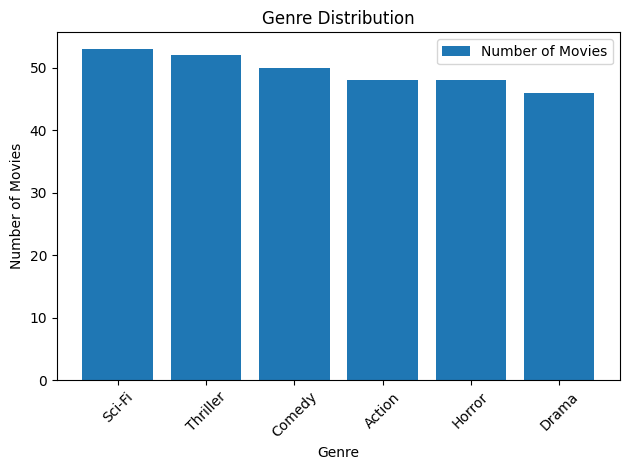

In [17]:
genre_counts = df_movies["Genre"].value_counts()

plt.figure()
plt.bar(genre_counts.index, genre_counts.values)
plt.title("Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.legend(["Number of Movies"])
plt.tight_layout()
plt.show()

## Subscription Type Distribution

The pie chart displays the proportion of users subscribed to each subscription tier. This visualisation helps assess the popularity of different pricing plans and provides insight into potential revenue distribution.

Variations in subscription type can reflect differences in user preferences, affordability, and engagement level. In a real-world scenario, such analysis would help the company optimise pricing strategies and promotional offers.

As this dataset is synthetic, the proportions were deliberately varied to simulate realistic user segmentation rather than producing uniform distributions.

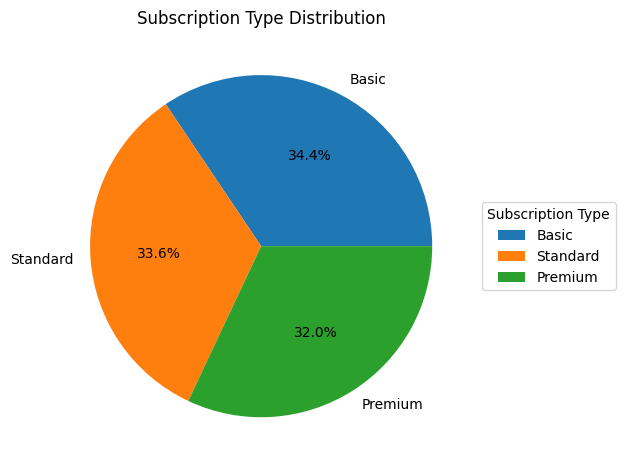

In [18]:
subscription_counts = df_users["Subscription_Type"].value_counts()

plt.figure()

plt.pie(
    subscription_counts.values,
    labels=subscription_counts.index,
    autopct="%1.1f%%"
)

plt.title("Subscription Type Distribution")

plt.legend(
    title="Subscription Type",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.show()

## User Engagement Over Time

The line graph illustrates user engagement trends over time, measured by watch activity. This helps identify behavioural patterns, growth trends, and potential seasonal fluctuations in platform usage.

Time-based engagement analysis is critical for streaming platforms, as it supports forecasting, infrastructure planning, and content release strategies.

Any sudden increases or decreases in activity should be interpreted cautiously, as the dataset is synthetically generated. Where necessary, engagement values were normalised to account for incomplete monthly records, ensuring a more accurate representation of activity trends.

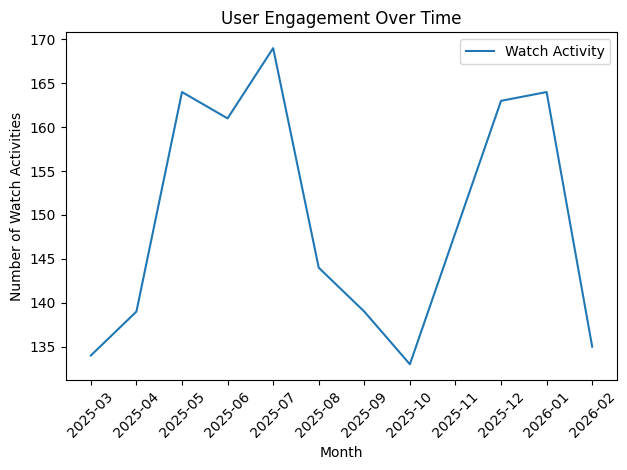

In [21]:
df_watch_history["Watch_Date"] = pd.to_datetime(df_watch_history["Watch_Date"])

monthly_counts = (
    df_watch_history
    .groupby(df_watch_history["Watch_Date"].dt.to_period("M"))
    .size()
)

# Remove last month (likely incomplete)
monthly_counts = monthly_counts.iloc[:-1]

plt.figure()
plt.plot(monthly_counts.index.astype(str), monthly_counts.values)
plt.title("User Engagement Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Watch Activities")
plt.xticks(rotation=45)
plt.legend(["Watch Activity"])
plt.tight_layout()
plt.show()

## Ethics and Data Privacy Considerations

Although this project uses synthetic data, ethical considerations remain important. Real-world streaming platforms collect sensitive user information such as personal identifiers, viewing history, and payment data.

Organisations handling such data must comply with regulations such as the General Data Protection Regulation (GDPR). This includes implementing secure data storage, restricting access to sensitive information, encrypting financial records, and ensuring transparency in data collection practices.

By generating artificial data and avoiding real personal information, this project demonstrates responsible and privacy-conscious database design.

## Limitations

As the dataset is synthetically generated, it may not perfectly reflect real-world behavioural distributions. Engagement trends and subscription patterns may appear smoother or more uniform than in actual streaming platforms.

Despite this limitation, the database structure accurately reflects how such systems are designed and maintained in practice.

## Conclusion

This project demonstrates the design and implementation of a relational database for a streaming platform. Through structured tables, foreign key relationships, and realistic synthetic data generation, the database successfully models user behaviour, content interaction, and financial transactions.

The design supports analytical queries, reporting, and meaningful insights while maintaining ethical standards and data integrity.